In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

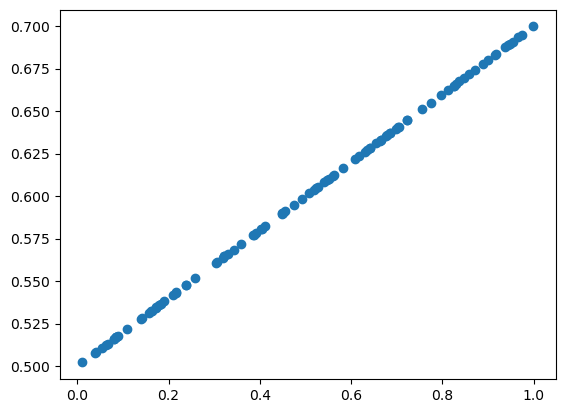

In [83]:
X = np.random.rand(100)
y = 0.2*X + 0.5
plt.scatter(X,y)


In [76]:
def plt_prediction(X, pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

Initial W, b : 0.04755188089228013 -0.4915026420114732
epoch 0, W: 0.3161, b: 0.0417, Error: 1.0665


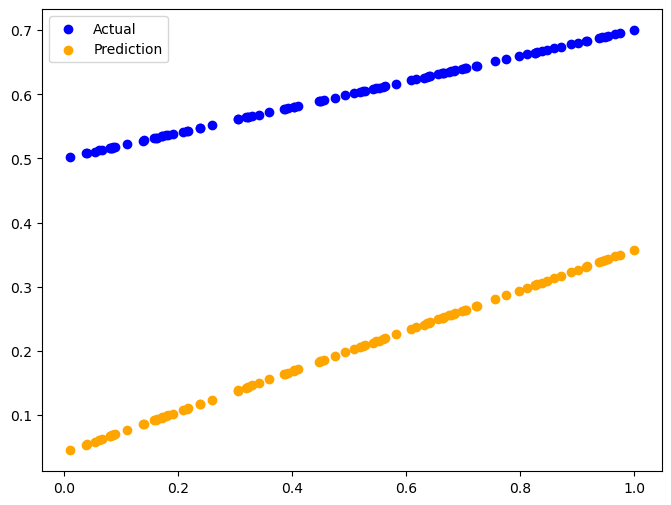

epoch 20, W: 0.3444, b: 0.4240, Error: 0.0371


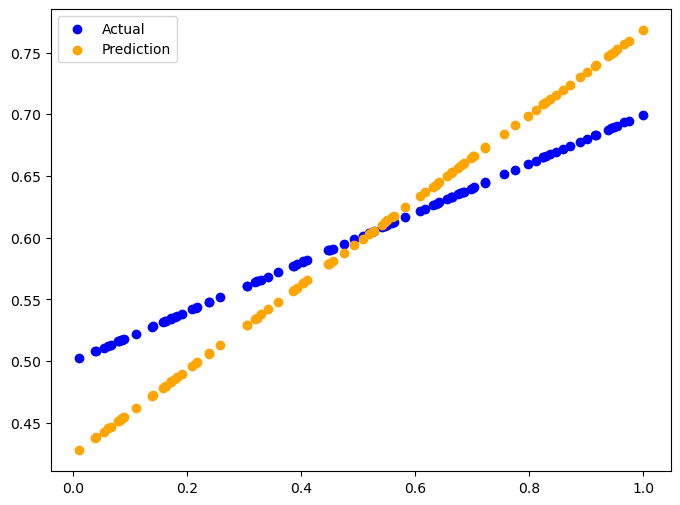

epoch 40, W: 0.2746, b: 0.4608, Error: 0.0191


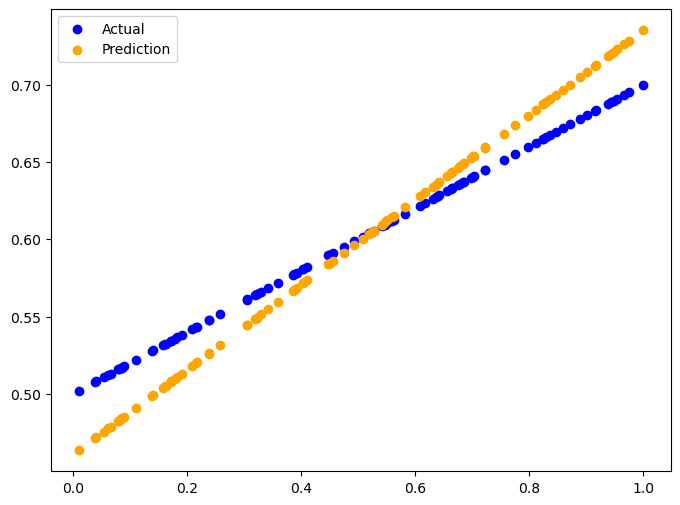

epoch 60, W: 0.2398, b: 0.4791, Error: 0.0099


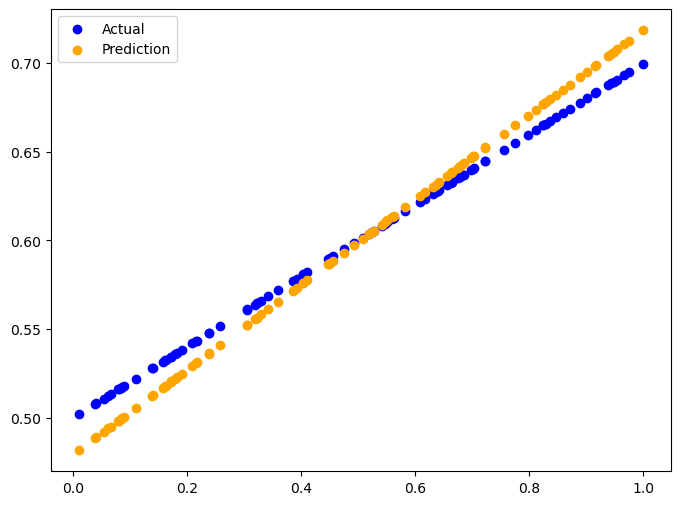

In [94]:
# 경사하강법
W = np.random.uniform(-1, 1)
b = np.random.uniform(-1, 1)

print("Initial W, b :", W, b)

learning_rate = 0.5 # 임의의 값

for epoch in range(100) :
    
    y_pred = W * X + b
    
    error = np.abs(y_pred - y).mean()
       
    if error < 0.01 : break
    
    W_descent = learning_rate * ((y_pred - y)*X).mean()
    b_descent = learning_rate * (y_pred - y).mean()
    
    W = W - W_descent
    b = b - b_descent
    
    if epoch%20 == 0 :
        print( f'epoch {epoch}, W: {W:.4f}, b: {b:.4f}, Error: {error:.4f}')
        y_pred = W * X + b
        plt_prediction(X, y_pred, y)
        
print( f'epoch {epoch}, W: {W:.4f}, b: {b:.4f}, Error: {error:.4f}')
y_pred = W * X + b
plt_prediction(X, y_pred, y)

# LinearRegression

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [50]:
from sklearn.datasets import fetch_california_housing

house = fetch_california_housing()
house_df = pd.DataFrame(house.data, columns=house.feature_names)
house_df['Price'] = house.target
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 분할

X = house_df.drop('Price', axis=1).values
y = house_df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Predict After Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# LinearRegression 모델 
house_lr = LinearRegression()
house_lr.fit(X_train, y_train)
y_pred = house_lr.predict(X_test)
y_pred[:10]

array([2.28110738, 2.79009128, 1.90332794, 1.01760331, 2.94852425,
       2.09053997, 2.99123876, 3.0566195 , 2.98022739, 2.38806029])

In [56]:
house_lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
from sklearn.metrics import mean_squared_error
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse


(np.float64(0.727312977360312), 0.5289841670367217)

In [55]:
r2_score(y_test, y_pred)

0.5943232652466197

In [57]:
#모델 학습 결과
house_lr.coef_, house_lr.intercept_

(array([ 4.33333407e-01,  9.29324337e-03, -9.86433739e-02,  5.93215487e-01,
        -7.56192502e-06, -4.74516383e-03, -4.21449336e-01, -4.34166041e-01]),
 np.float64(-36.85856910680125))

In [58]:
#회귀계수의 확인
pd.Series(data = np.round(house_lr.coef_,1), 
          index=house_df.drop('Price', axis=1).columns).sort_values(ascending=False)

AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

# 다항회귀모델 (Polynomial Regression Model)   
PolynomialFeatures 클래스

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [92]:
features_poly = PolynomialFeatures(degree=2, include_bias=False)
model_poly = Pipeline([('poly', features_poly), ('linear', LinearRegression())])

model_poly.fit(X_train, y_train)


poly_pred = model_poly.predict(X_test)

mean_squared_error(y_test, y_pred)

ValueError: Found input variables with inconsistent numbers of samples: [4128, 100]

In [60]:
results = []
best_r2=-np.inf
best_model = None
best_pred = None

for degree in range(1,5):
  model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
    ('linear', LinearRegression())]
  )
  model_poly.fit(X_train, y_train)
  pred_poly = model_poly.predict(X_test)
  mse = mean_squared_error(y_test, pred_poly)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, pred_poly)
  
  results.append({ 'degree':degree,
                  'MSE':mse,
                  'RMSE':rmse,
                  'R2': r2})
  if r2> best_r2:
    best_r2 = r2
    best_model = model_poly
    best_pred = pred_poly
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,5.289842e-01,0.727313,5.943233e-01
1,2,2.763846e+00,1.662482,-1.119587e+00
2,3,5.205124e+04,228.147416,-3.991698e+04
3,4,2.125341e+06,1457.854832,-1.629918e+06


# 규제회귀모델 (Regularized Regression Model)  

In [66]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [61]:
# 3. 릿지 회귀
ridge = Ridge(alpha=1.0)  # alpha는 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("\n[릿지 회귀]")
print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))


[릿지 회귀]
MSE: 0.5290047234158008
R2: 0.5943075006070277


In [62]:
from sklearn.linear_model import Lasso
# 4. 라쏘 회귀

lasso = Lasso(alpha=0.1)  # alpha 값 작으면 규제 약해짐
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\n[라쏘 회귀]")
print("MSE:", mean_squared_error(y_test, pred_lasso))
print("R2:", r2_score(y_test, pred_lasso))


[라쏘 회귀]
MSE: 0.6196149319559707
R2: 0.5248187411573575


In [63]:
from sklearn.linear_model import RidgeCV

# 테스트해보고 싶은 alpha 값 리스트
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print(f"최적의 alpha: {ridge_cv.alpha_}")

최적의 alpha: 100.0


In [64]:
from sklearn.linear_model import RidgeCV, LassoCV

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
lasso_preds = lasso_cv.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)
lasso_r2

0.5938011386599713

In [67]:
# 5. 엘라스틱넷 회귀
model_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5: L1과 L2의 비중 50:50
model_enet.fit(X_train, y_train)
pred_enet = model_enet.predict(X_test)

print("\n[엘라스틱넷 회귀]")
print("MSE:", mean_squared_error(y_test, pred_enet))
print("R2:", r2_score(y_test, pred_enet))


[엘라스틱넷 회귀]
MSE: 0.5772440253364033
R2: 0.557312891487519
